In [4]:
import sys, os

# ── Fix 1: make `src` importable ──────────────────────────────────────────────
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# ── Fix 2: move CWD to project root so relative paths in config.yaml work ────
os.chdir(project_root)

print("CWD:", os.getcwd())       # should be: .../Loan-Risk-Intelligence
print("sys.path[0]:", sys.path[0])

from src.utils.config import load_config, get_project_root
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score
from scipy.stats import chi2
import numpy as np
import pandas as pd

# ── Define output_dir ─────────────────────────────────────────
config     = load_config()
output_dir = Path(get_project_root()) / config["paths"]["outputs"]

y_test    = pd.read_parquet(output_dir / "y_test.parquet").squeeze().values
xgb_probs = pd.read_parquet(output_dir / "xgb_predictions.parquet")["y_prob_xgb"].values
nn_probs  = pd.read_parquet(output_dir / "nn_predictions.parquet")["y_prob_nn"].values

# ── McNemar's Test ────────────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
def best_threshold(probs, y):
    scores = [f1_score(y, probs >= t, zero_division=0) for t in thresholds]
    return thresholds[np.argmax(scores)]

thresh_xgb = best_threshold(xgb_probs, y_test)
thresh_nn  = best_threshold(nn_probs,  y_test)
pred_xgb   = (xgb_probs >= thresh_xgb).astype(int)
pred_nn    = (nn_probs  >= thresh_nn).astype(int)

n01 = ((pred_xgb == 0) & (pred_nn == 1) & (y_test == 1)).sum()
n10 = ((pred_xgb == 1) & (pred_nn == 0) & (y_test == 1)).sum()
mcnemar_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
p_value = 1 - chi2.cdf(mcnemar_stat, df=1)
print(f"McNemar: stat={mcnemar_stat:.4f} | p={p_value:.6f} | n01={n01} | n10={n10}")

# ── Bootstrap CI ─────────────────────────────────────────────
rng = np.random.default_rng(42)
diffs = []
for _ in range(1000):
    idx = rng.integers(0, len(y_test), len(y_test))
    diffs.append(
        roc_auc_score(y_test[idx], nn_probs[idx]) -
        roc_auc_score(y_test[idx], xgb_probs[idx])
    )
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI (NN - XGB): [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Winner: {'NN' if ci_low > 0 else 'XGB' if ci_high < 0 else 'No significant difference'}")


CWD: c:\college\PROJECTS
sys.path[0]: c:\college\PROJECTS
McNemar: stat=194.7552 | p=0.000000 | n01=1154 | n10=1930
Bootstrap 95% CI (NN - XGB): [0.0006, 0.0011]
Winner: NN


SHAP values shape: (540686, 60)


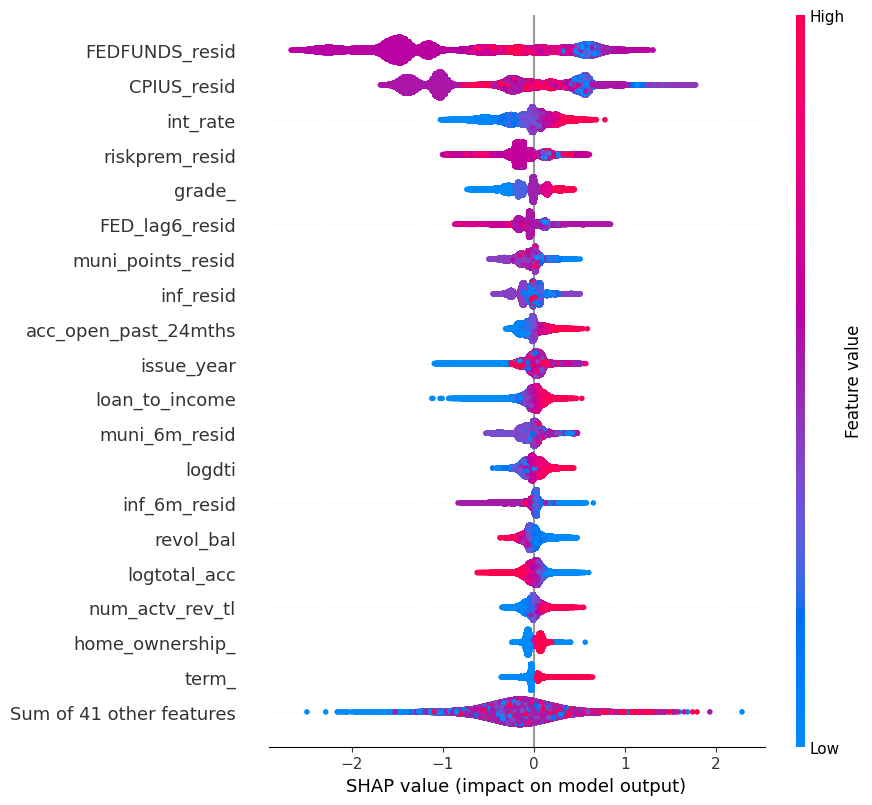

In [5]:
import shap
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path

X_test = pd.read_parquet(output_dir / "X_test.parquet")

# Load the saved XGBoost model
model = xgb.XGBClassifier()
model.load_model(str(output_dir / "xgb_model.json"))

# TreeExplainer — exact SHAP values, fast on XGBoost
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)          # full 360K rows, ~2–3 min

# Save for Model 2 dataset generation later
np.save(output_dir / "shap_values.npy", shap_values.values)
print(f"SHAP values shape: {shap_values.values.shape}")  # (360457, 60)

# Global beeswarm — top 20 features
shap.plots.beeswarm(shap_values, max_display=20)


CWD: c:\college\PROJECTS\ML\Loan-Risk-Intelligence
sys.path[0]: c:\college\PROJECTS\ML\Loan-Risk-Intelligence

── LOW_RISK | prob=0.042 | actual=0.0 ──


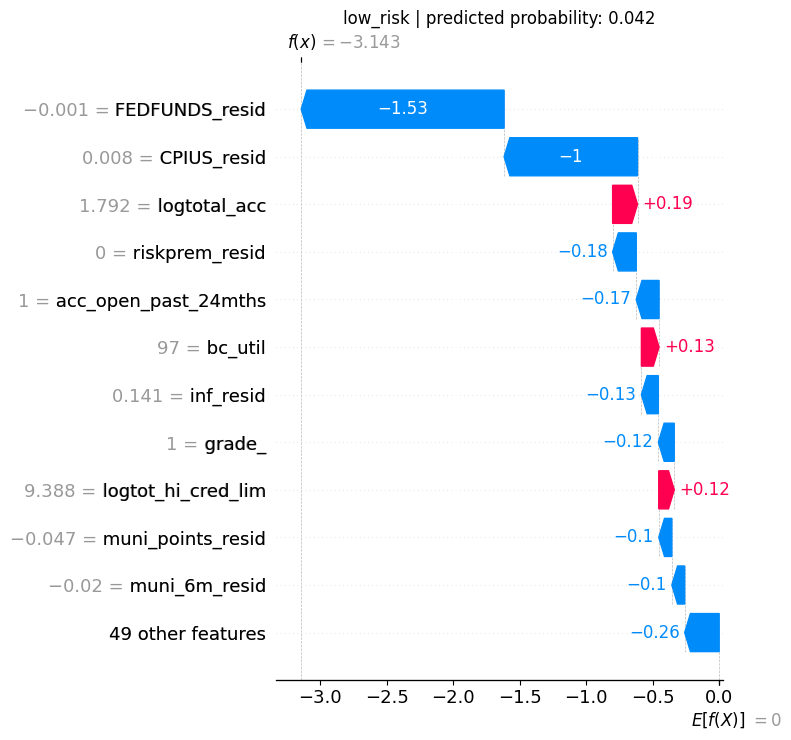


── MEDIUM_RISK | prob=0.364 | actual=1.0 ──


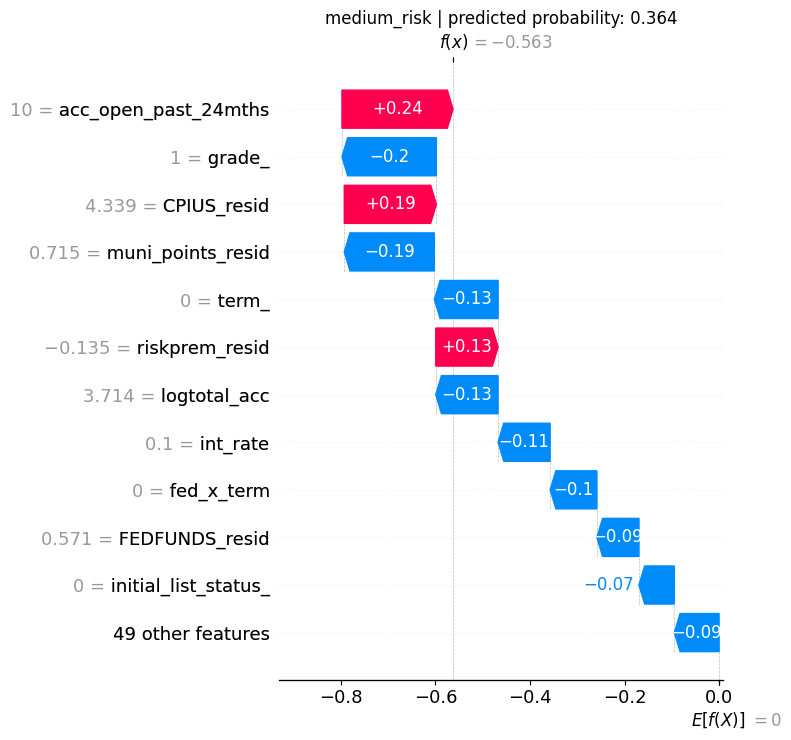


── HIGH_RISK | prob=0.899 | actual=1.0 ──


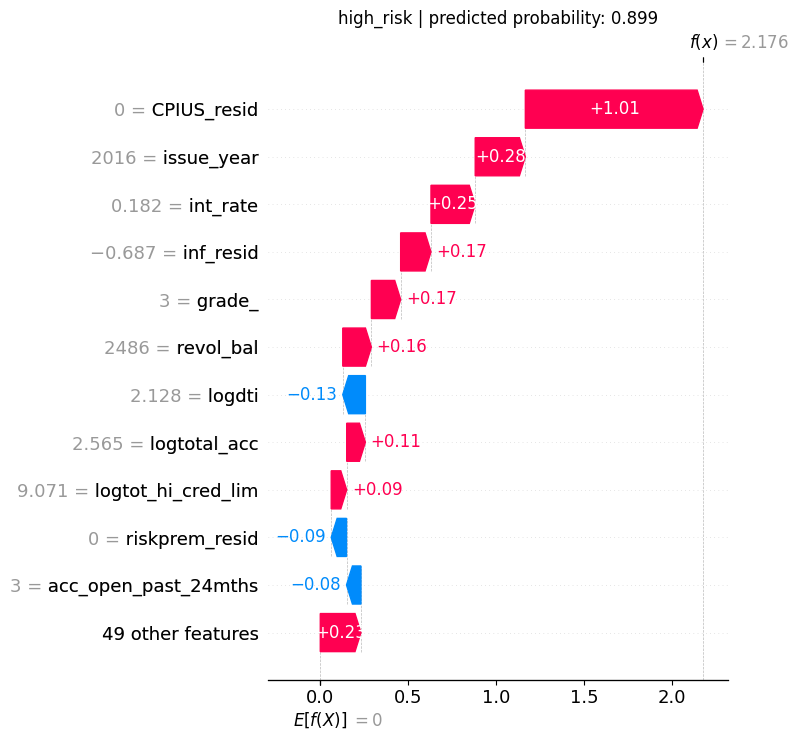

In [2]:
import sys, os

# ── Fix 1: make `src` importable ──────────────────────────────────────────────
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# ── Fix 2: move CWD to project root so relative paths in config.yaml work ────
os.chdir(project_root)

print("CWD:", os.getcwd())       # should be: .../Loan-Risk-Intelligence
print("sys.path[0]:", sys.path[0])
from src.utils.config import load_config, get_project_root
from pathlib import Path
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

config     = load_config()
output_dir = Path(get_project_root()) / config["paths"]["outputs"]

# ── Load everything from disk — NO recomputation ──────────────
X_test          = pd.read_parquet(output_dir / "X_test.parquet")
y_test          = pd.read_parquet(output_dir / "y_test.parquet").squeeze().values
shap_values_arr = np.load(output_dir / "shap_values.npy")        # instant load

model = xgb.XGBClassifier()
model.load_model(str(output_dir / "xgb_model.json"))
probs = model.predict_proba(X_test)[:, 1]

# ── Reconstruct shap Explanation object ───────────────────────
explainer   = shap.TreeExplainer(model)
base_value  = explainer.expected_value                            # single float, instant
shap_exp    = shap.Explanation(
    values          = shap_values_arr,
    base_values     = np.full(len(X_test), base_value),
    data            = X_test.values,
    feature_names   = X_test.columns.tolist()
)

# ── Pick 3 loans ──────────────────────────────────────────────
low_idx  = np.where((probs < 0.15) & (y_test == 0))[0][0]
mid_idx  = np.where((probs > 0.35) & (probs < 0.55) & (y_test == 1))[0][0]
high_idx = np.where((probs > 0.75) & (y_test == 1))[0][0]

# ── Waterfall plots — each takes < 1 second ───────────────────
for label, idx in [("low_risk", low_idx), ("medium_risk", mid_idx), ("high_risk", high_idx)]:
    print(f"\n── {label.upper()} | prob={probs[idx]:.3f} | actual={y_test[idx]} ──")
    shap.plots.waterfall(shap_exp[idx], max_display=12, show=False)
    plt.title(f"{label} | predicted probability: {probs[idx]:.3f}")
    plt.tight_layout()
    plt.savefig(output_dir / f"shap_waterfall_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()
